# Compute budget for Illustris

In [21]:
import os
import re
import numpy as np
from collections import defaultdict

class LOOResultLoader:
    def __init__(self, base_dir="./results"):
        self.base_dir = base_dir
        self.results = defaultdict(lambda: defaultdict(list))  # results[LF][HF] = [list of runs]
        self._load_all()

    def _load_all(self):
        """Internal method to scan and load all result folders."""
        pattern = re.compile(r"LF(\d+)_HF(\d+)_Holdout(\d+)")
        for folder in os.listdir(self.base_dir):
            match = pattern.match(folder)
            if match:
                num_LF, num_HF, holdout_idx = map(int, match.groups())
                folder_path = os.path.join(self.base_dir, folder)

                try:
                    data = {
                        "predictions": np.loadtxt(os.path.join(folder_path, "predictions.txt")),
                        "variances": np.loadtxt(os.path.join(folder_path, "variances.txt")),
                        "pred_over_exact": np.loadtxt(os.path.join(folder_path, "pred_over_exact.txt")),
                        "residuals": np.loadtxt(os.path.join(folder_path, "residuals.txt")),
                    }
                    mse_path = os.path.join(folder_path, "mean_squared_error.txt")
                    if os.path.exists(mse_path):
                        data["mse"] = float(np.loadtxt(mse_path))
                    data["holdout_idx"] = holdout_idx
                    self.results[num_LF][num_HF].append(data)
                except Exception as e:
                    print(f"Failed to load {folder_path}: {e}")

    def get_all_LF(self):
        return sorted(self.results.keys())

    def get_all_HF(self, num_LF):
        return sorted(self.results[num_LF].keys())

    def get_results(self, num_LF, num_HF):
        """Returns list of result dicts for specific (LF, HF)."""
        return self.results[num_LF][num_HF]

    def get_mse_matrix(self):
        """Returns a matrix (num_LF x num_HF) of averaged MSEs."""
        lf_list = self.get_all_LF()
        hf_list = self.get_all_HF(lf_list[0])  # assume same across all LF
        mse_mat = np.zeros((len(lf_list), len(hf_list)))
        for i, lf in enumerate(lf_list):
            for j, hf in enumerate(hf_list):
                mses = [r.get("mse", np.nan) for r in self.get_results(lf, hf)]
                mse_mat[i, j] = np.nanmean(mses)
        return lf_list, hf_list, mse_mat

    def get_relative_error_matrix(self):
        """Returns a matrix (num_LF x num_HF) of average relative errors: mean(|pred/exact - 1|)."""
        lf_list = self.get_all_LF()
        hf_list = self.get_all_HF(lf_list[0])  # assume shared HF config
        relerr_mat = np.zeros((len(lf_list), len(hf_list)))

        for i, lf in enumerate(lf_list):
            for j, hf in enumerate(hf_list):
                rel_errors = []
                for r in self.get_results(lf, hf):
                    pred_over_exact = r.get("pred_over_exact")
                    if pred_over_exact is not None:
                        rel_err = np.mean(np.abs(pred_over_exact - 1))
                        rel_errors.append(rel_err)
                relerr_mat[i, j] = np.nanmean(rel_errors) if rel_errors else np.nan
        return lf_list, hf_list, relerr_mat    

Failed to load ../../results_loo/LF500_HF3_Holdout0: ../../results_loo/LF500_HF3_Holdout0/predictions.txt not found.
LFs: [100, 300, 500, 700, 900, 1004]
HFs for LF=100: [1, 2, 3, 4, 5, 6, 7]
Number of runs for LF=300, HF=3: 4
Shape of predictions: (10,)


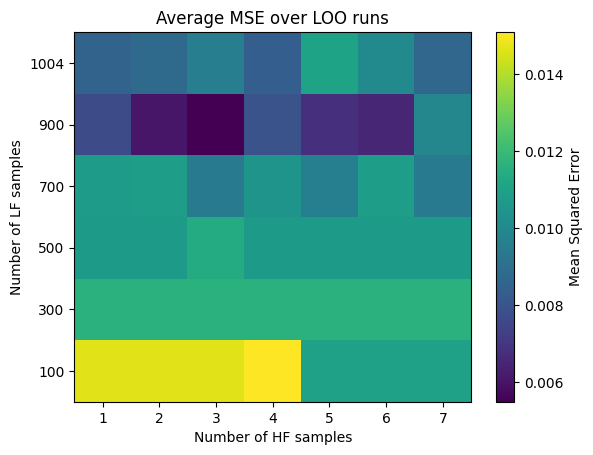

In [22]:
loader = LOOResultLoader("../../results_loo")

# List LF and HF configurations
print("LFs:", loader.get_all_LF())
print("HFs for LF=100:", loader.get_all_HF(100))

# Access predictions for LF=200, HF=3
results = loader.get_results(300, 3)
print("Number of runs for LF=300, HF=3:", len(results))
print("Shape of predictions:", results[0]['predictions'].shape)

# Plot average MSE as heatmap
import matplotlib.pyplot as plt

lf_list, hf_list, mse_matrix = loader.get_mse_matrix()
plt.imshow(mse_matrix, origin='lower', cmap='viridis', aspect='auto')
plt.xticks(np.arange(len(hf_list)), hf_list)
plt.yticks(np.arange(len(lf_list)), lf_list)
plt.colorbar(label="Mean Squared Error")
plt.xlabel("Number of HF samples")
plt.ylabel("Number of LF samples")
plt.title("Average MSE over LOO runs")
plt.show()

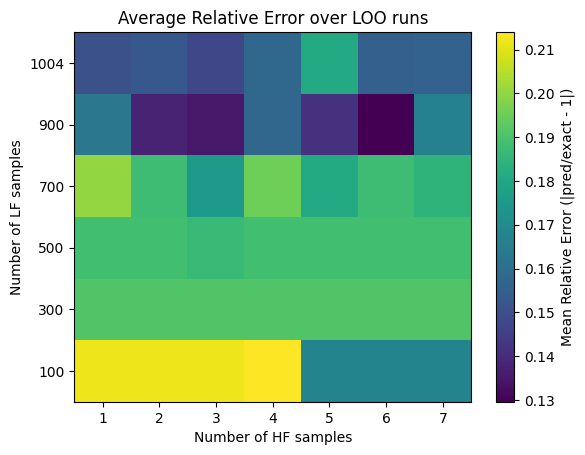

In [24]:
lf_list, hf_list, relerr_matrix = loader.get_relative_error_matrix()

plt.imshow(relerr_matrix, origin='lower', cmap='viridis', aspect='auto')
plt.xticks(np.arange(len(hf_list)), hf_list)
plt.yticks(np.arange(len(lf_list)), lf_list)
plt.colorbar(label="Mean Relative Error (|pred/exact - 1|)")
plt.xlabel("Number of HF samples")
plt.ylabel("Number of LF samples")
plt.title("Average Relative Error over LOO runs")
plt.show()

In [25]:
def relerr_model(nL, nH, eta, rho, alpha_L, alpha1, alpha2, beta_L, beta1, beta2):
    term1 = rho / ((nL + nH) * (nL + alpha_L)**(beta_L - 1) * (nH + alpha1)**(beta1 - 1))
    term2 = 1 / (nH + alpha2)**beta2
    return eta * (term1 + term2)

from scipy.optimize import curve_fit

# Prepare meshgrid of LF and HF values (same shape as relerr_matrix)
lf_list, hf_list, relerr_matrix = loader.get_relative_error_matrix()
nL_vals, nH_vals = np.meshgrid(lf_list, hf_list, indexing="ij")
xdata = np.vstack([nL_vals.ravel(), nH_vals.ravel()])  # shape: (2, N)
ydata = relerr_matrix.ravel()

# Remove NaNs before fitting
mask = ~np.isnan(ydata)
xdata_fit = xdata[:, mask]
ydata_fit = ydata[mask]

# Initial guesses for parameters
p0 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# Fit
popt, pcov = curve_fit(lambda X, eta, rho, alpha_L, alpha1, alpha2, beta_L, beta1, beta2:
                       relerr_model(X[0], X[1], eta, rho, alpha_L, alpha1, alpha2, beta_L, beta1, beta2),
                       xdata_fit, ydata_fit, p0=p0)

# Unpack fitted parameters
eta, rho, alpha_L, alpha1, alpha2, beta_L, beta1, beta2 = popt
print("Fitted parameters:")
print(f"eta = {eta:.3f}, rho = {rho:.3f}, alpha_L = {alpha_L:.3f}, alpha1 = {alpha1:.3f}, alpha2 = {alpha2:.3f},")
print(f"beta_L = {beta_L:.3f}, beta1 = {beta1:.3f}, beta2 = {beta2:.3f}")

Fitted parameters:
eta = 0.460, rho = 2.153, alpha_L = -41.404, alpha1 = -0.901, alpha2 = 11.330,
beta_L = 0.259, beta1 = 1.009, beta2 = 5.902


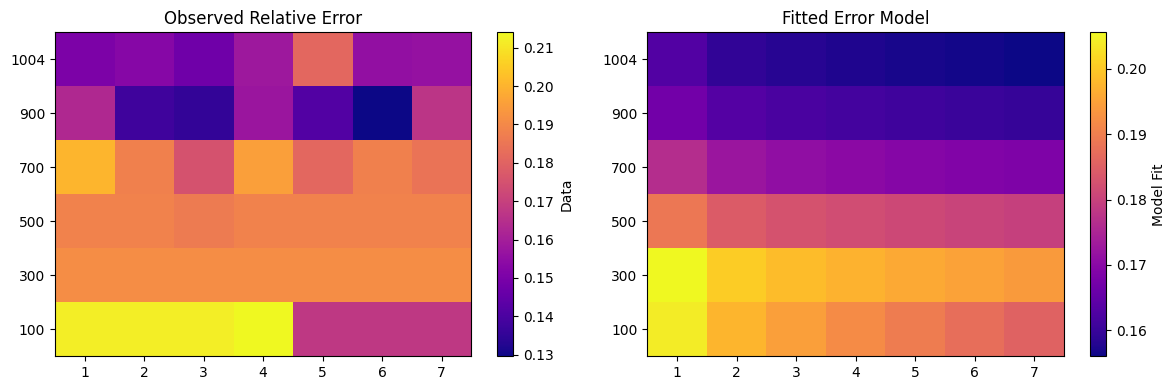

In [26]:
relerr_fit = relerr_model(nL_vals, nH_vals, *popt)

plt.figure(figsize=(12, 4))

# Data
plt.subplot(1, 2, 1)
plt.imshow(relerr_matrix, origin='lower', cmap='plasma', aspect='auto')
plt.xticks(np.arange(len(hf_list)), hf_list)
plt.yticks(np.arange(len(lf_list)), lf_list)
plt.colorbar(label="Data")
plt.title("Observed Relative Error")

# Model
plt.subplot(1, 2, 2)
plt.imshow(relerr_fit, origin='lower', cmap='plasma', aspect='auto')
plt.xticks(np.arange(len(hf_list)), hf_list)
plt.yticks(np.arange(len(lf_list)), lf_list)
plt.colorbar(label="Model Fit")
plt.title("Fitted Error Model")

plt.tight_layout()
plt.show()

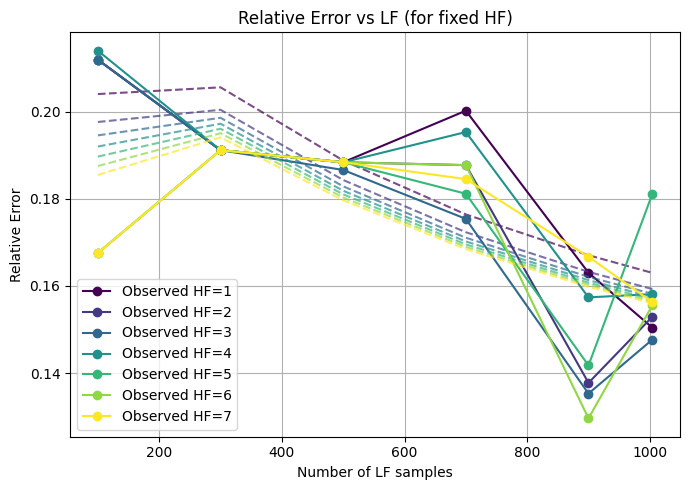

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(hf_list)))

for j, hf in enumerate(hf_list):
    obs_curve = [relerr_matrix[i, j] for i in range(len(lf_list))]
    fit_curve = [relerr_model(lf, hf, *popt) for lf in lf_list]

    plt.plot(lf_list, obs_curve, marker='o', label=f'Observed HF={hf}', color=colors[j])
    plt.plot(lf_list, fit_curve, ls='--', color=colors[j], alpha=0.7)

plt.xlabel("Number of LF samples")
plt.ylabel("Relative Error")
plt.title("Relative Error vs LF (for fixed HF)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

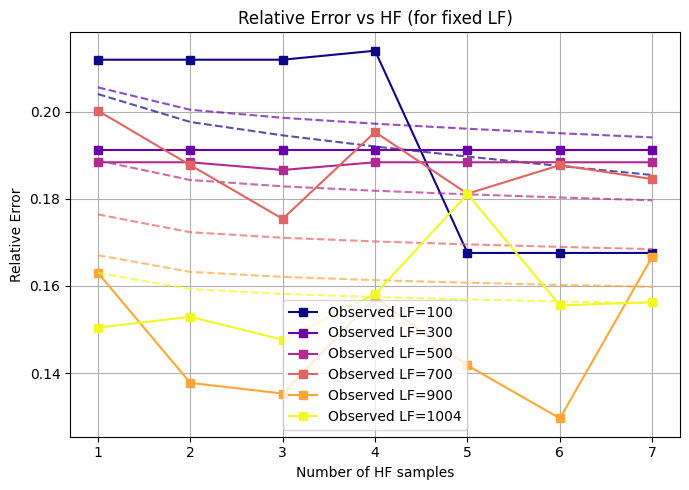

In [28]:
plt.figure(figsize=(7, 5))
colors = plt.cm.plasma(np.linspace(0, 1, len(lf_list)))

for i, lf in enumerate(lf_list):
    obs_curve = [relerr_matrix[i, j] for j in range(len(hf_list))]
    fit_curve = [relerr_model(lf, hf, *popt) for hf in hf_list]

    plt.plot(hf_list, obs_curve, marker='s', label=f'Observed LF={lf}', color=colors[i])
    plt.plot(hf_list, fit_curve, ls='--', color=colors[i], alpha=0.7)

plt.xlabel("Number of HF samples")
plt.ylabel("Relative Error")
plt.title("Relative Error vs HF (for fixed LF)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Failed to load ../../results_loo/LF500_HF3_Holdout0: ../../results_loo/LF500_HF3_Holdout0/predictions.txt not found.


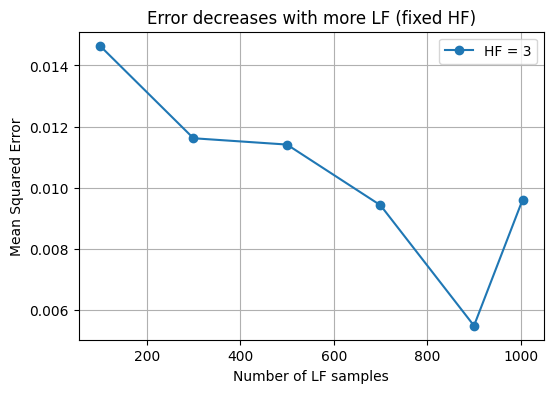

In [6]:
# Initialize loader
loader = LOOResultLoader("../../results_loo")

# Get available LF and HF values
lf_list = loader.get_all_LF()
hf_list = loader.get_all_HF(lf_list[0])  # assume HF configs are shared across LF

# Plot: Error vs. LF (for a fixed HF count)
hf_fixed = 3  # choose HF=3 as example
mse_vs_lf = []
for lf in lf_list:
    results = loader.get_results(lf, hf_fixed)
    mses = [r.get("mse", np.nan) for r in results]
    mse_vs_lf.append(np.nanmean(mses))

plt.figure(figsize=(6, 4))
plt.plot(lf_list, mse_vs_lf, marker='o', label=f'HF = {hf_fixed}')
plt.xlabel("Number of LF samples")
plt.ylabel("Mean Squared Error")
plt.title("Error decreases with more LF (fixed HF)")
plt.grid(True)
plt.legend()
plt.show()

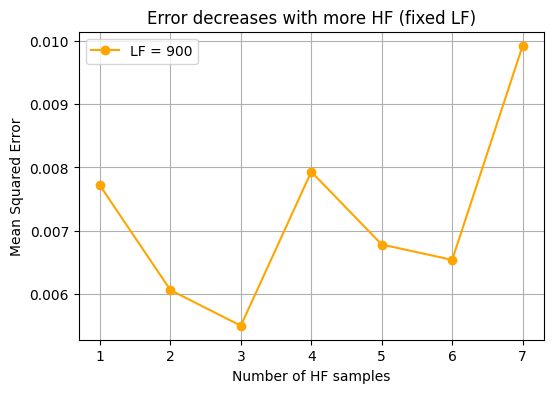

In [16]:
# Plot: Error vs. HF (for a fixed LF count)
lf_fixed = 900 # choose LF=500 as example
mse_vs_hf = []
for hf in hf_list:
    results = loader.get_results(lf_fixed, hf)
    mses = [r.get("mse", np.nan) for r in results]
    mse_vs_hf.append(np.nanmean(mses))

plt.figure(figsize=(6, 4))
plt.plot(hf_list, mse_vs_hf, marker='o', color='orange', label=f'LF = {lf_fixed}')
plt.xlabel("Number of HF samples")
plt.ylabel("Mean Squared Error")
plt.title("Error decreases with more HF (fixed LF)")
plt.grid(True)
plt.legend()
plt.show()